In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("salaryprediction.csv")
df.head()

,Name,JobTitle,AgencyID,Agency,HireDate,AnnualSalary,GrossPay
0,"Aaron,Keontae E",AIDE BLUE CHIP,W02200,Youth Summer,06/10/2013,$11310.00,$873.63
1,"Aaron,Patricia G",Facilities/Office Services II,A03031,OED-Employment Dev,10/24/1979,$53428.00,$52868.38
2,"Aaron,Petra L",ASSISTANT STATE'S ATTORNEY,A29005,States Attorneys Office,09/25/2006,$68300.00,$67439.19
3,"Abaineh,Yohannes T",EPIDEMIOLOGIST,A65026,HLTH-Health Department,07/23/2009,$62000.00,$58654.74
4,"Abbene,Anthony M",POLICE OFFICER TRAINEE,A99416,Police Department,07/24/2013,$43999.00,$39686.95


In [3]:
df.shape

(18981, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18981 entries, 0 to 18980
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0    Name         18981 non-null  object
 1   JobTitle      18981 non-null  object
 2   AgencyID      18981 non-null  object
 3   Agency        18981 non-null  object
 4   HireDate      18911 non-null  object
 5   AnnualSalary  18981 non-null  object
 6   GrossPay      15758 non-null  object
dtypes: object(7)
memory usage: 1.0+ MB


In [5]:
df.describe()

,Name,JobTitle,AgencyID,Agency,HireDate,AnnualSalary,GrossPay
count,18981,18981,18981,18981,18911,18981,15758
unique,18788,1075,1177,65,4737,1590,13732
top,"Battle,Daron J",AIDE BLUE CHIP,P04001,Youth Summer,05/21/2014,$11310.00,$1051.25
freq,2,4817,316,4323,1478,4811,848


In [6]:
df.columns

Index([' Name', 'JobTitle', 'AgencyID', 'Agency', 'HireDate', 'AnnualSalary',
       'GrossPay'],
      dtype='object')

In [7]:
df.columns=df.columns.str.strip()
df.columns

Index(['Name', 'JobTitle', 'AgencyID', 'Agency', 'HireDate', 'AnnualSalary',
       'GrossPay'],
      dtype='object')

In [8]:
for i in df.columns:
    df[i]=df[i].str.strip()

In [9]:
len(df.columns)

7

In [10]:
df['Name']=df['Name'].apply(lambda x : x.lower())
df['JobTitle']=df['JobTitle'].apply(lambda x : x.lower())
df['AgencyID']=df['AgencyID'].apply(lambda x : x.lower())
df['Agency']=df['Agency'].apply(lambda x : x.lower())

In [11]:
df.head()

,Name,JobTitle,AgencyID,Agency,HireDate,AnnualSalary,GrossPay
0,"aaron,keontae e",aide blue chip,w02200,youth summer,06/10/2013,$11310.00,$873.63
1,"aaron,patricia g",facilities/office services ii,a03031,oed-employment dev,10/24/1979,$53428.00,$52868.38
2,"aaron,petra l",assistant state's attorney,a29005,states attorneys office,09/25/2006,$68300.00,$67439.19
3,"abaineh,yohannes t",epidemiologist,a65026,hlth-health department,07/23/2009,$62000.00,$58654.74
4,"abbene,anthony m",police officer trainee,a99416,police department,07/24/2013,$43999.00,$39686.95


In [12]:
df['year']=pd.to_datetime(df['HireDate']).dt.year
df['month']=pd.to_datetime(df['HireDate']).dt.month
df['day']=pd.to_datetime(df['HireDate']).dt.day

In [13]:
df['AnnualSalary']=df['AnnualSalary'].apply(lambda x : x[1:])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18981 entries, 0 to 18980
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          18981 non-null  object 
 1   JobTitle      18981 non-null  object 
 2   AgencyID      18981 non-null  object 
 3   Agency        18981 non-null  object 
 4   HireDate      18911 non-null  object 
 5   AnnualSalary  18981 non-null  object 
 6   GrossPay      15758 non-null  object 
 7   year          18911 non-null  float64
 8   month         18911 non-null  float64
 9   day           18911 non-null  float64
dtypes: float64(3), object(7)
memory usage: 1.4+ MB


In [15]:
df['AnnualSalary']=pd.to_numeric(df['AnnualSalary'])

In [16]:
df=df.drop_duplicates()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18981 entries, 0 to 18980
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          18981 non-null  object 
 1   JobTitle      18981 non-null  object 
 2   AgencyID      18981 non-null  object 
 3   Agency        18981 non-null  object 
 4   HireDate      18911 non-null  object 
 5   AnnualSalary  18981 non-null  float64
 6   GrossPay      15758 non-null  object 
 7   year          18911 non-null  float64
 8   month         18911 non-null  float64
 9   day           18911 non-null  float64
dtypes: float64(4), object(6)
memory usage: 1.4+ MB


In [18]:
df.head()

,Name,JobTitle,AgencyID,Agency,HireDate,AnnualSalary,GrossPay,year,month,day
0,"aaron,keontae e",aide blue chip,w02200,youth summer,06/10/2013,11310.0,$873.63,2013.0,6.0,10.0
1,"aaron,patricia g",facilities/office services ii,a03031,oed-employment dev,10/24/1979,53428.0,$52868.38,1979.0,10.0,24.0
2,"aaron,petra l",assistant state's attorney,a29005,states attorneys office,09/25/2006,68300.0,$67439.19,2006.0,9.0,25.0
3,"abaineh,yohannes t",epidemiologist,a65026,hlth-health department,07/23/2009,62000.0,$58654.74,2009.0,7.0,23.0
4,"abbene,anthony m",police officer trainee,a99416,police department,07/24/2013,43999.0,$39686.95,2013.0,7.0,24.0


In [19]:
df.isnull().sum()

Name               0
JobTitle           0
AgencyID           0
Agency             0
HireDate          70
AnnualSalary       0
GrossPay        3223
year              70
month             70
day               70
dtype: int64

In [20]:
df.shape

(18981, 10)

In [21]:
(70/df.shape[0])*100

0.368789842474053

In [22]:
df.dropna(subset='HireDate',inplace=True)

In [23]:
df['HireDate'].isnull().sum()

0

In [24]:
df.isnull().sum()

Name               0
JobTitle           0
AgencyID           0
Agency             0
HireDate           0
AnnualSalary       0
GrossPay        3223
year               0
month              0
day                0
dtype: int64

In [25]:
df['year']=df['year'].astype('int')
df['month']=df['month'].astype('int')
df['day']=df['day'].astype('int')

In [26]:
df.head()

,Name,JobTitle,AgencyID,Agency,HireDate,AnnualSalary,GrossPay,year,month,day
0,"aaron,keontae e",aide blue chip,w02200,youth summer,06/10/2013,11310.0,$873.63,2013,6,10
1,"aaron,patricia g",facilities/office services ii,a03031,oed-employment dev,10/24/1979,53428.0,$52868.38,1979,10,24
2,"aaron,petra l",assistant state's attorney,a29005,states attorneys office,09/25/2006,68300.0,$67439.19,2006,9,25
3,"abaineh,yohannes t",epidemiologist,a65026,hlth-health department,07/23/2009,62000.0,$58654.74,2009,7,23
4,"abbene,anthony m",police officer trainee,a99416,police department,07/24/2013,43999.0,$39686.95,2013,7,24


In [27]:
df.drop(columns=['HireDate','GrossPay'],inplace=True)
df.head()

,Name,JobTitle,AgencyID,Agency,AnnualSalary,year,month,day
0,"aaron,keontae e",aide blue chip,w02200,youth summer,11310.0,2013,6,10
1,"aaron,patricia g",facilities/office services ii,a03031,oed-employment dev,53428.0,1979,10,24
2,"aaron,petra l",assistant state's attorney,a29005,states attorneys office,68300.0,2006,9,25
3,"abaineh,yohannes t",epidemiologist,a65026,hlth-health department,62000.0,2009,7,23
4,"abbene,anthony m",police officer trainee,a99416,police department,43999.0,2013,7,24


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18911 entries, 0 to 18980
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          18911 non-null  object 
 1   JobTitle      18911 non-null  object 
 2   AgencyID      18911 non-null  object 
 3   Agency        18911 non-null  object 
 4   AnnualSalary  18911 non-null  float64
 5   year          18911 non-null  int32  
 6   month         18911 non-null  int32  
 7   day           18911 non-null  int32  
dtypes: float64(1), int32(3), object(4)
memory usage: 1.1+ MB


In [29]:
df['Name']

0             aaron,keontae e
1            aaron,patricia g
2               aaron,petra l
3          abaineh,yohannes t
4            abbene,anthony m
                 ...         
18976    zotamou,jean marie d
18977         zotamou,pivot d
18978    zovistoski,zachary d
18979       zubyk,stanislav t
18980      zukowski,charles j
Name: Name, Length: 18911, dtype: object

In [30]:
df['JobTitle'].nunique()

1060

In [31]:
df['JobTitle'].value_counts()

JobTitle
aide blue chip                    4817
police officer                    1866
laborer (hourly)                   597
crossing guard                     374
emt firefighter suppression        358
                                  ... 
supt communications/computer o       1
vehicle damage investigator          1
accounting systems analyst           1
desk top publishing coordinato       1
president city council               1
Name: count, Length: 1060, dtype: int64

1060


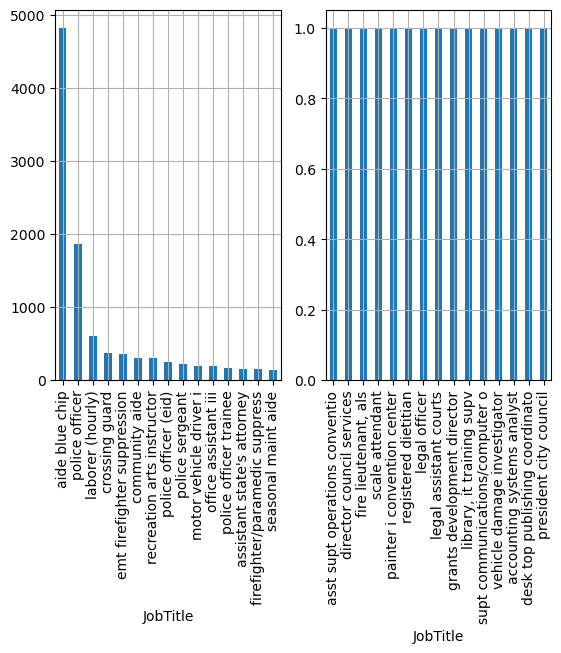

In [32]:
print(df['JobTitle'].nunique())
plt.subplot(1,2,1)
df['JobTitle'].value_counts().head(15).plot(kind='bar')
plt.grid()
plt.subplot(1,2,2)
df['JobTitle'].value_counts().tail(15).plot(kind='bar')
plt.grid()

In [33]:
df['Agency'].nunique()

64

In [34]:
df['Agency'].value_counts()

Agency
youth summer                4817
police department           3141
fire department             1576
dpw-water & waste water     1491
hlth-health department       833
                            ... 
m-r labor commissioner         6
hlth-health dept locatio       6
legislative reference          5
m-r cable & comm               4
special city services          4
Name: count, Length: 64, dtype: int64

64


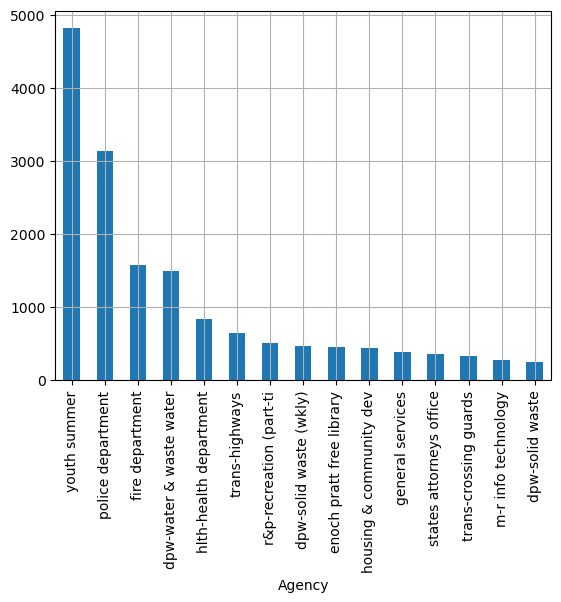

In [35]:
print(df['Agency'].nunique())
df['Agency'].value_counts().head(15).plot.bar()
plt.grid()

1177


<Axes: xlabel='AgencyID'>

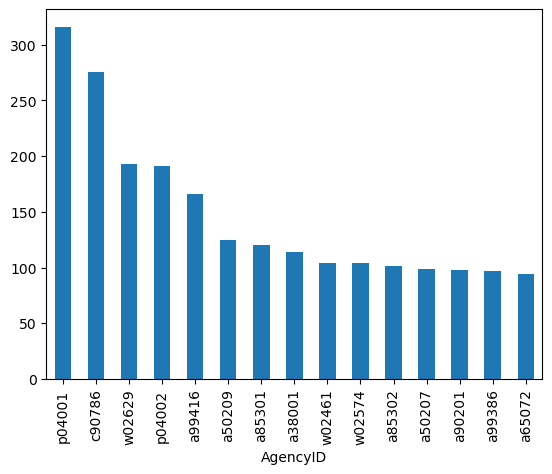

In [36]:
print(df['AgencyID'].nunique())
df['AgencyID'].value_counts().head(15).plot.bar()

In [37]:
df

,Name,JobTitle,AgencyID,Agency,AnnualSalary,year,month,day
0,"aaron,keontae e",aide blue chip,w02200,youth summer,11310.0,2013,6,10
1,"aaron,patricia g",facilities/office services ii,a03031,oed-employment dev,53428.0,1979,10,24
2,"aaron,petra l",assistant state's attorney,a29005,states attorneys office,68300.0,2006,9,25
3,"abaineh,yohannes t",epidemiologist,a65026,hlth-health department,62000.0,2009,7,23
4,"abbene,anthony m",police officer trainee,a99416,police department,43999.0,2013,7,24
...,...,...,...,...,...,...,...,...
18976,"zotamou,jean marie d",aide blue chip,w02235,youth summer,11310.0,2014,5,21
18977,"zotamou,pivot d",aide blue chip,w02629,youth summer,11310.0,2014,5,21
18978,"zovistoski,zachary d",police officer trainee,a99416,police department,43999.0,2013,12,17
18979,"zubyk,stanislav t",police officer,a99262,police department,44104.0,2013,1,23


In [38]:
df.shape


(18911, 8)

<Axes: >

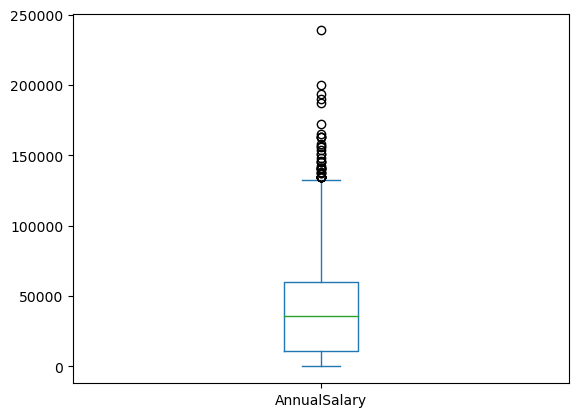

In [39]:
df.AnnualSalary.plot.box()

In [40]:
df.AnnualSalary.describe()

count     18911.000000
mean      39660.421889
std       25163.465942
min           0.000000
25%       11310.000000
50%       36203.000000
75%       60300.000000
max      238772.000000
Name: AnnualSalary, dtype: float64

In [41]:
df= df[df['AnnualSalary']<140000]

<Axes: >

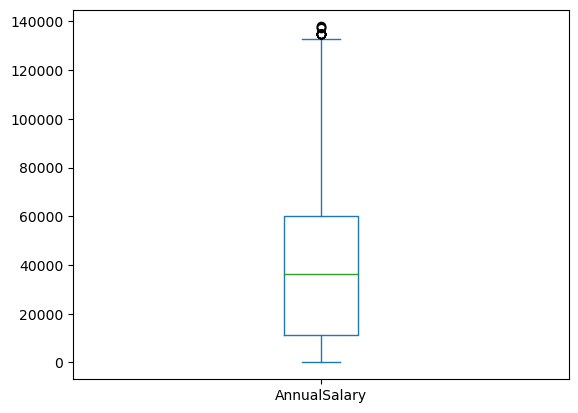

In [42]:
df.AnnualSalary.plot.box()

In [43]:
df.shape

(18885, 8)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2988\820057994.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.AnnualSalary)


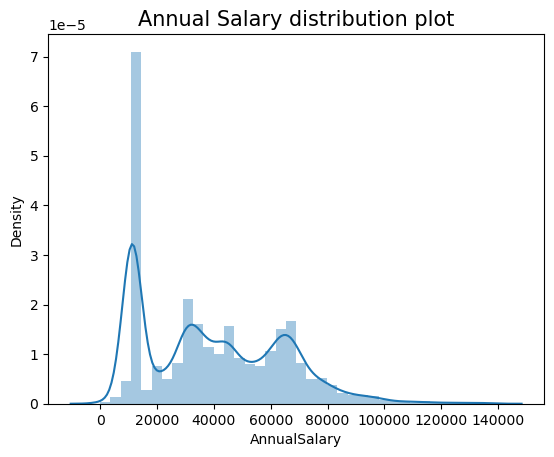

In [44]:
sns.distplot(df.AnnualSalary)
plt.title("Annual Salary distribution plot", fontsize=15)
plt.show()

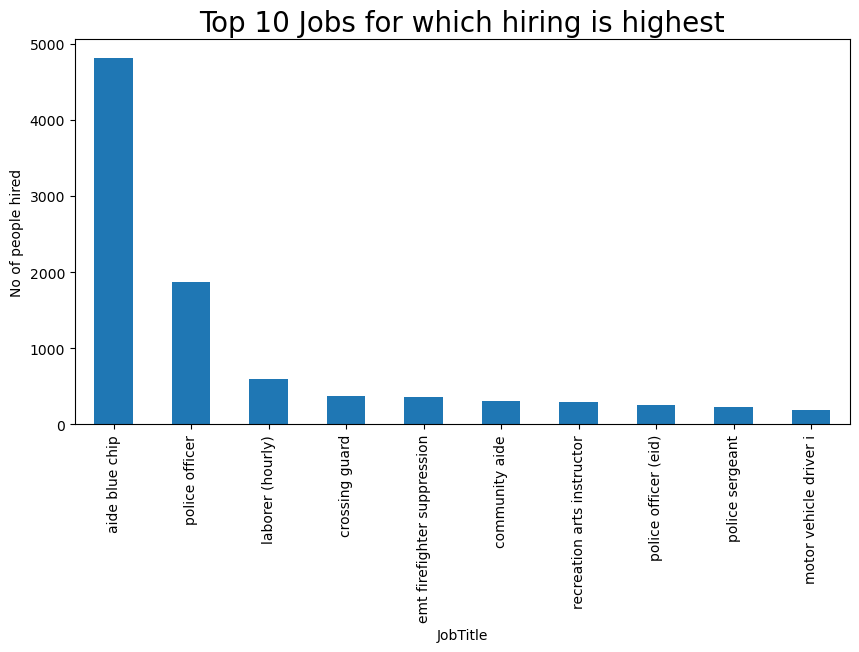

In [45]:
plt.figure(figsize=(10,5))
df.groupby(['JobTitle'])['Name'].count().sort_values(ascending=False).head(10).plot.bar()
plt.ylabel("No of people hired")
plt.title('Top 10 Jobs for which hiring is highest', fontsize=20)
plt.show()

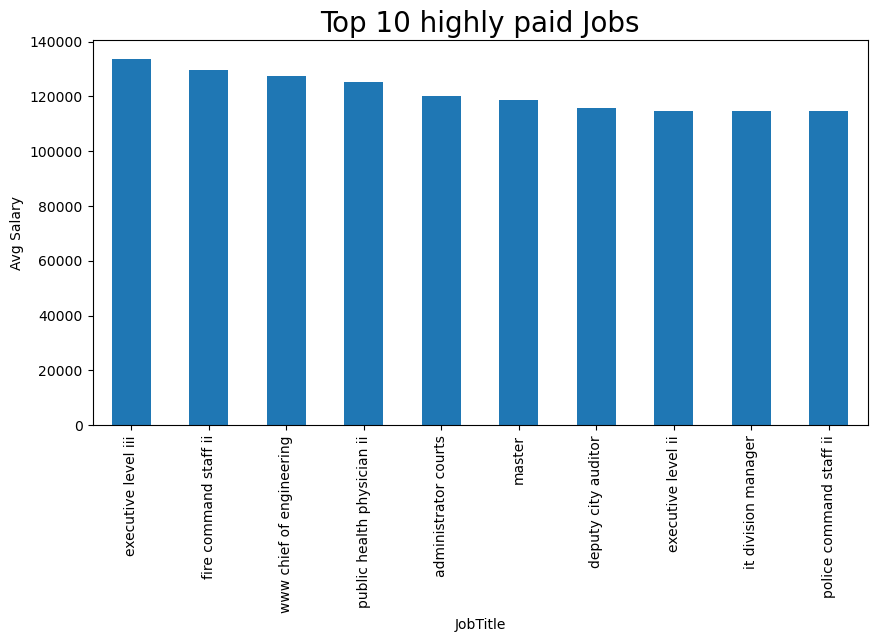

In [46]:
plt.figure(figsize=(10,5))
df.groupby(['JobTitle'])['AnnualSalary'].mean().sort_values(ascending=False).head(10).plot.bar()
plt.ylabel("Avg Salary")
plt.title('Top 10 highly paid Jobs', fontsize=20)
plt.show()

In [47]:
# mean salary
mean_salary = df.AnnualSalary.mean()
# nunber of jobs paying more than mean salory
good_paying_jobs = df.groupby(['JobTitle'])['AnnualSalary'].mean().reset_index()
good_paying_jobs[good_paying_jobs.AnnualSalary>mean_salary]['JobTitle'].count()

797

In [48]:
good_paying_jobs

,JobTitle,AnnualSalary
0,911 lead operator,47886.000000
1,911 operator,42835.743590
2,911 operator supervisor,54797.500000
3,account executive,42960.000000
4,accountant i,46316.642857
...,...,...
1049,zoning administrator,82100.000000
1050,zoning appeals advisor bmza,59274.000000
1051,zoning enforcement officer,62000.000000
1052,zoning examiner i,43674.000000


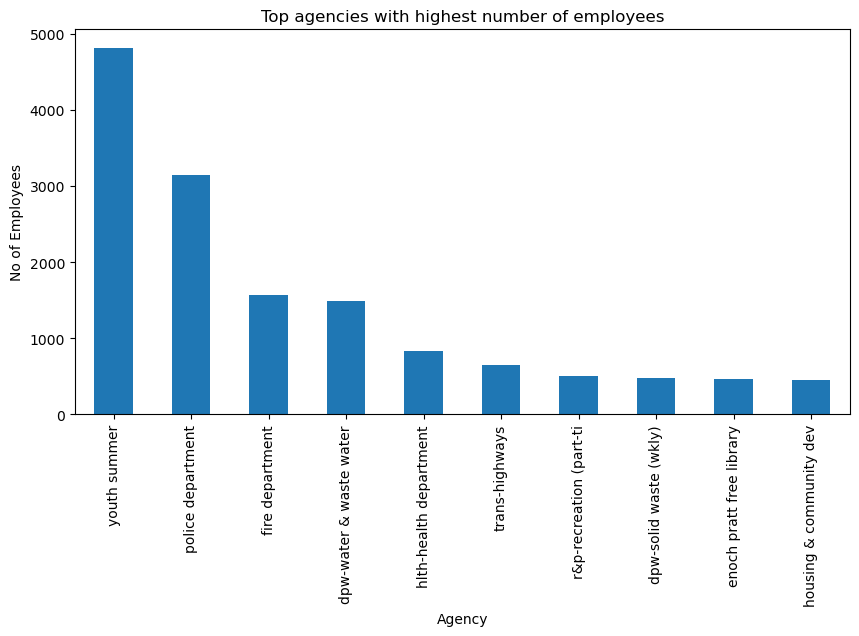

In [49]:
plt.figure(figsize=(10,5))
df.groupby(['Agency'])['Name'].count().sort_values(ascending=False).head(10).plot.bar()
plt.ylabel("No of Employees")
plt.title('Top agencies with highest number of employees')
plt.show()

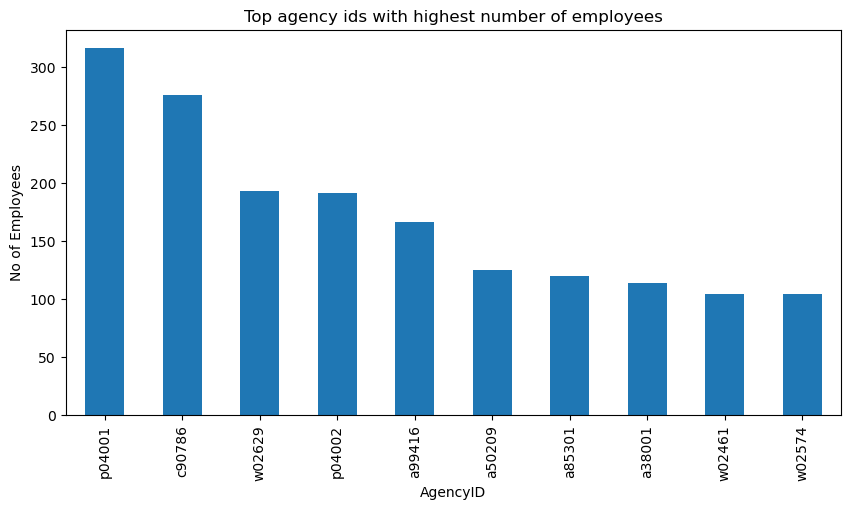

In [50]:
plt.figure(figsize=(10,5))
df.groupby(['AgencyID'])['Name'].count().sort_values(ascending=False).head(10).plot.bar()
plt.ylabel("No of Employees")
plt.title('Top agency ids with highest number of employees')
plt.show()

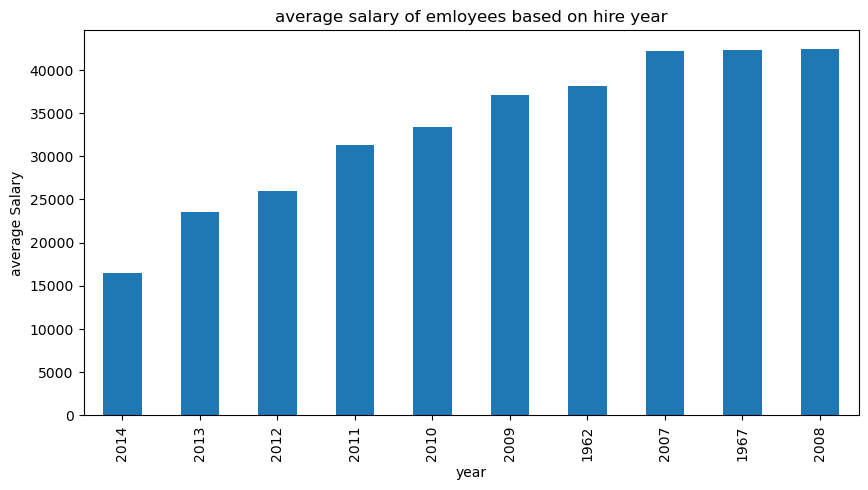

In [51]:
plt.figure(figsize=(10,5))
df.groupby(['year'])['AnnualSalary'].mean().sort_values().head(10).plot.bar()
plt.ylabel("average Salary")
plt.title('average salary of emloyees based on hire year')
plt.show()

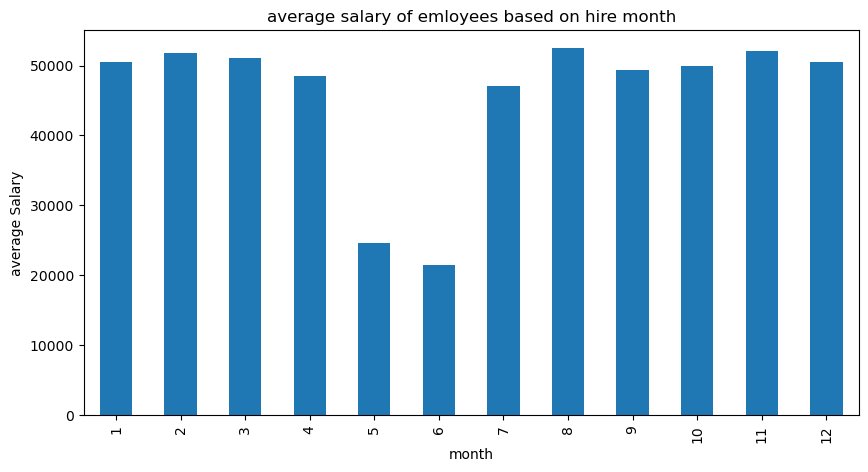

In [52]:
plt.figure(figsize=(10,5))
df.groupby(['month'])['AnnualSalary'].mean().plot.bar()
plt.ylabel("average Salary")
plt.title('average salary of emloyees based on hire month')
plt.show()

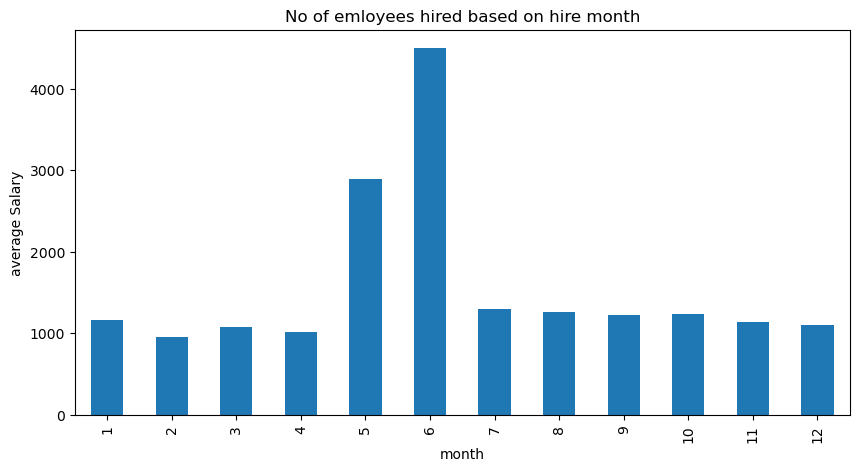

In [53]:
plt.figure(figsize=(10,5))
df.groupby(['month'])['Name'].count().plot.bar()
plt.ylabel("average Salary")
plt.title('No of emloyees hired based on hire month')
plt.show()

D:\anacondaa__\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1500x2000 with 0 Axes>

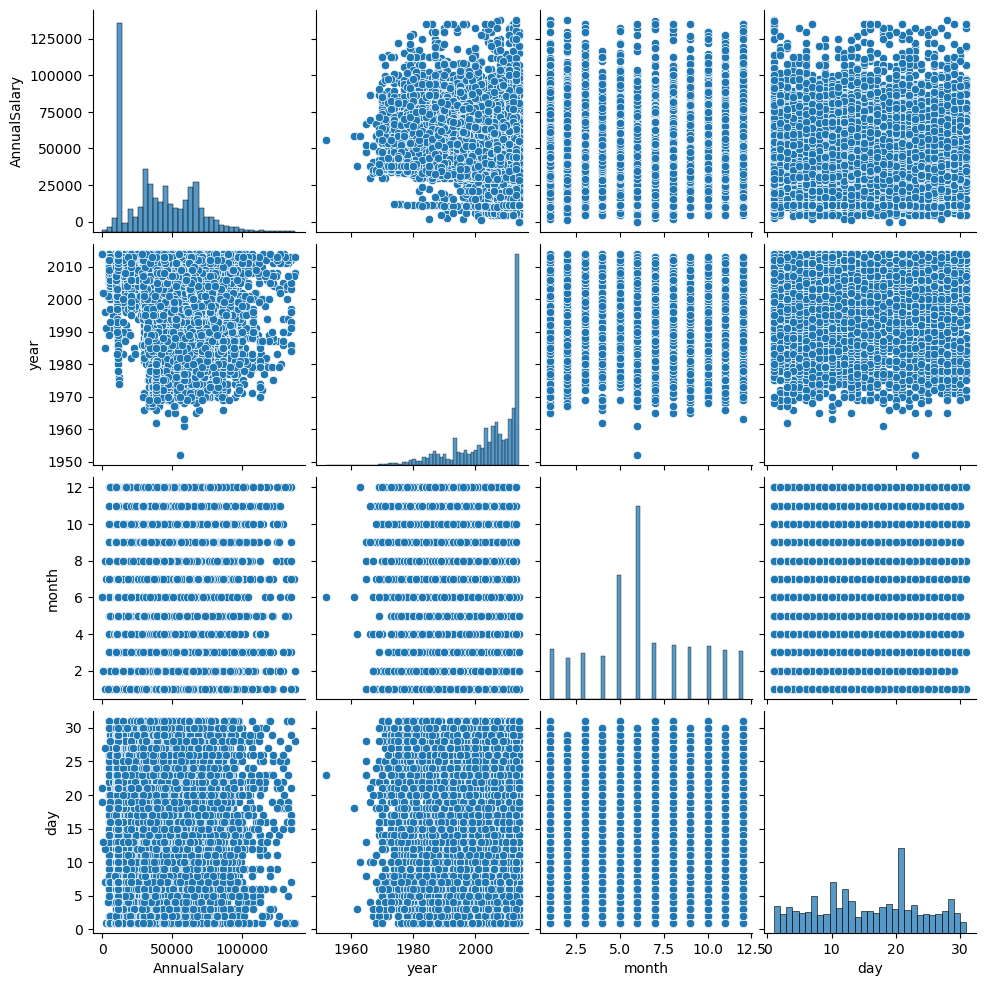

In [54]:
plt.figure(figsize=(15,20))
sns.pairplot(df)
plt.show()

In [55]:
df_master = df.copy()

In [56]:
# Apply mean encoding for job title
mean_job = df_master.groupby("JobTitle")["AnnualSalary"].mean()
df_master['JobTitle'] = df_master["JobTitle"].map(mean_job)
df_master['JobTitle']

0        11313.967200
1        47443.500000
2        69750.666667
3        57940.000000
4        44531.160494
             ...     
18976    11313.967200
18977    11313.967200
18978    44531.160494
18979    60588.139335
18980    53368.428571
Name: JobTitle, Length: 18885, dtype: float64

In [57]:
# Apply mean encoding for agency
mean_agency = df_master.groupby("Agency")["AnnualSalary"].mean()
df_master['Agency'] = df_master["Agency"].map(mean_agency)
df_master['Agency']

0        11313.967200
1        51495.424242
2        64874.560224
3        39980.900360
4        61481.005417
             ...     
18976    11313.967200
18977    11313.967200
18978    61481.005417
18979    61481.005417
18980    42565.513078
Name: Agency, Length: 18885, dtype: float64

In [58]:
# Apply mean encoding for agencyid
mean_agencyid = df_master.groupby("AgencyID")["AnnualSalary"].mean()
df_master['AgencyID'] = df_master["AgencyID"].map(mean_agencyid)
df_master['AgencyID']

0        11310.000000
1        46667.000000
2        65926.133333
3        48071.851064
4        44012.307229
             ...     
18976    11310.000000
18977    11310.000000
18978    44012.307229
18979    60203.340426
18980    42407.562500
Name: AgencyID, Length: 18885, dtype: float64

In [59]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18885 entries, 0 to 18980
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          18885 non-null  object 
 1   JobTitle      18885 non-null  float64
 2   AgencyID      18885 non-null  float64
 3   Agency        18885 non-null  float64
 4   AnnualSalary  18885 non-null  float64
 5   year          18885 non-null  int32  
 6   month         18885 non-null  int32  
 7   day           18885 non-null  int32  
dtypes: float64(4), int32(3), object(1)
memory usage: 1.1+ MB


In [60]:
# dropping Name and hiredate column
df_master = df_master.drop(['Name'],axis=1)
df_master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18885 entries, 0 to 18980
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   JobTitle      18885 non-null  float64
 1   AgencyID      18885 non-null  float64
 2   Agency        18885 non-null  float64
 3   AnnualSalary  18885 non-null  float64
 4   year          18885 non-null  int32  
 5   month         18885 non-null  int32  
 6   day           18885 non-null  int32  
dtypes: float64(4), int32(3)
memory usage: 959.0 KB


In [61]:
# train test split
salary_train , salary_test = train_test_split(df_master,train_size=0.7,random_state=10)

In [62]:
print(salary_train.shape)
print(salary_test.shape)

(13219, 7)
(5666, 7)


In [63]:
# dividing training data into dependent and independent variables
y_train = salary_train.pop("AnnualSalary")
x_train = salary_train

In [64]:
# dividing testing data into dependent and independent variables
y_test = salary_test.pop("AnnualSalary")
x_test = salary_test

In [65]:
x_train

,JobTitle,AgencyID,Agency,year,month,day
2110,21570.423841,21474.446429,31494.602740,2007,3,26
7529,11313.967200,11310.000000,11313.967200,2014,6,16
15366,11313.967200,11310.000000,11313.967200,2013,6,10
3237,11313.967200,11310.000000,11313.967200,2009,6,11
16659,11313.967200,11310.000000,11313.967200,2014,6,19
...,...,...,...,...,...,...
9453,11313.967200,11310.000000,11313.967200,2014,5,21
7371,29925.666667,33754.400000,31594.490526,2002,3,4
17822,34098.128205,38263.434783,31494.602740,1999,5,27
7373,42275.081081,62661.900000,62661.900000,1969,10,6


In [66]:
y_train

2110     19802.0
7529     11310.0
15366    11310.0
3237     11310.0
16659    11310.0
          ...   
9453     11310.0
7371     30119.0
17822    36370.0
7373     47382.0
17767    36282.0
Name: AnnualSalary, Length: 13219, dtype: float64

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [68]:
# feature scaling
scaler=StandardScaler()
x_train[x_train.columns] = scaler.fit_transform(x_train[x_train.columns])
x_train.describe()

,JobTitle,AgencyID,Agency,year,month,day
count,1.321900e+04,1.321900e+04,1.321900e+04,1.321900e+04,1.321900e+04,1.321900e+04
mean,6.665202e-17,1.343791e-16,3.870117e-17,-7.609080e-15,-5.321411e-17,8.062744e-18
std,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00
min,-1.546632e+00,-1.691969e+00,-1.397343e+00,-4.138882e+00,-1.822288e+00,-1.763380e+00
25%,-1.162446e+00,-1.272054e+00,-1.345816e+00,-5.827611e-01,-4.642147e-01,-8.086782e-01
50%,-1.457188e-01,9.319493e-02,1.459947e-01,2.822413e-01,-1.246964e-01,2.668601e-02
75%,8.700324e-01,9.033706e-01,1.048937e+00,8.589095e-01,8.938587e-01,7.427125e-01
max,3.889902e+00,2.886953e+00,1.959063e+00,9.550209e-01,1.912414e+00,1.816752e+00


In [69]:
x_test[x_test.columns] = scaler.fit_transform(x_test[x_test.columns])

In [70]:
# model building
model = LinearRegression()
result = model.fit(x_train,y_train)

In [71]:
model.score(x_train,y_train)

0.9652498067695456

In [72]:
model.score(x_test,y_test)

0.9647181159099966

In [73]:
print(model.coef_)
print(model.intercept_)

[22107.57351879  2772.01552827 -1638.49731197 -2104.19216623
  -103.80442772   -78.87693955]
39505.76539904681


In [74]:
y_pred = model.predict(x_test)

In [75]:
y_test

9797     59409.0
4541     11310.0
2860     11310.0
8139     66231.0
2876     40303.0
          ...   
11213    40954.0
3366     69900.0
11606    57900.0
14382    65480.0
394      11310.0
Name: AnnualSalary, Length: 5666, dtype: float64